In [1]:
import pandas as pd
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('diamonds.csv')
data.head()

,carat,cut,color,clarity,depth,table,price
0,0.23,Ideal,E,SI2,61.5,55.0,326
1,0.21,Premium,E,SI1,59.8,61.0,326
2,0.23,Good,E,VS1,56.9,65.0,327
3,0.29,Premium,I,VS2,62.4,58.0,334
4,0.31,Good,J,SI2,63.3,58.0,335


In [3]:
data.tail()

,carat,cut,color,clarity,depth,table,price
53935,0.72,Ideal,D,SI1,60.8,57.0,2757
53936,0.72,Good,D,SI1,63.1,55.0,2757
53937,0.70,Very Good,D,SI1,62.8,60.0,2757
53938,0.86,Premium,H,SI2,61.0,58.0,2757
53939,0.75,Ideal,D,SI2,62.2,55.0,2757


In [4]:
data.shape

(53940, 7)

In [5]:
data.columns

Index(['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price'], dtype='object')

In [6]:
data.isnull().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
dtype: int64

In [7]:
data.info

<bound method DataFrame.info of        carat        cut color clarity  depth  table  price
0       0.23      Ideal     E     SI2   61.5   55.0    326
1       0.21    Premium     E     SI1   59.8   61.0    326
2       0.23       Good     E     VS1   56.9   65.0    327
3       0.29    Premium     I     VS2   62.4   58.0    334
4       0.31       Good     J     SI2   63.3   58.0    335
...      ...        ...   ...     ...    ...    ...    ...
53935   0.72      Ideal     D     SI1   60.8   57.0   2757
53936   0.72       Good     D     SI1   63.1   55.0   2757
53937   0.70  Very Good     D     SI1   62.8   60.0   2757
53938   0.86    Premium     H     SI2   61.0   58.0   2757
53939   0.75      Ideal     D     SI2   62.2   55.0   2757

[53940 rows x 7 columns]>

In [8]:
data.describe

<bound method NDFrame.describe of        carat        cut color clarity  depth  table  price
0       0.23      Ideal     E     SI2   61.5   55.0    326
1       0.21    Premium     E     SI1   59.8   61.0    326
2       0.23       Good     E     VS1   56.9   65.0    327
3       0.29    Premium     I     VS2   62.4   58.0    334
4       0.31       Good     J     SI2   63.3   58.0    335
...      ...        ...   ...     ...    ...    ...    ...
53935   0.72      Ideal     D     SI1   60.8   57.0   2757
53936   0.72       Good     D     SI1   63.1   55.0   2757
53937   0.70  Very Good     D     SI1   62.8   60.0   2757
53938   0.86    Premium     H     SI2   61.0   58.0   2757
53939   0.75      Ideal     D     SI2   62.2   55.0   2757

[53940 rows x 7 columns]>

In [9]:
data.isnull()

,carat,cut,color,clarity,depth,table,price
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
53935,False,False,False,False,False,False,False
53936,False,False,False,False,False,False,False
53937,False,False,False,False,False,False,False
53938,False,False,False,False,False,False,False


In [10]:
data.duplicated

<bound method DataFrame.duplicated of        carat        cut color clarity  depth  table  price
0       0.23      Ideal     E     SI2   61.5   55.0    326
1       0.21    Premium     E     SI1   59.8   61.0    326
2       0.23       Good     E     VS1   56.9   65.0    327
3       0.29    Premium     I     VS2   62.4   58.0    334
4       0.31       Good     J     SI2   63.3   58.0    335
...      ...        ...   ...     ...    ...    ...    ...
53935   0.72      Ideal     D     SI1   60.8   57.0   2757
53936   0.72       Good     D     SI1   63.1   55.0   2757
53937   0.70  Very Good     D     SI1   62.8   60.0   2757
53938   0.86    Premium     H     SI2   61.0   58.0   2757
53939   0.75      Ideal     D     SI2   62.2   55.0   2757

[53940 rows x 7 columns]>

In [11]:
data.duplicated().sum()

np.int64(803)

In [12]:
data.dtypes

carat      float64
cut         object
color       object
clarity     object
depth      float64
table      float64
price        int64
dtype: object

In [13]:
data.color.unique()

array(['E', 'I', 'J', 'H', 'F', 'G', 'D'], dtype=object)

In [14]:
data.cut.unique()

array(['Ideal', 'Premium', 'Good', 'Very Good', 'Fair'], dtype=object)

In [15]:
data.clarity.unique()

array(['SI2', 'SI1', 'VS1', 'VS2', 'VVS2', 'VVS1', 'I1', 'IF'],
      dtype=object)

In [16]:
data.depth.unique()

array([61.5, 59.8, 56.9, 62.4, 63.3, 62.8, 62.3, 61.9, 65.1, 59.4, 64. ,
       60.4, 62.2, 60.2, 60.9, 62. , 63.4, 63.8, 62.7, 61. , 58.1, 62.5,
       60.5, 60. , 60.7, 59.5, 58.2, 64.1, 60.8, 61.8, 61.2, 61.1, 65.2,
       58.4, 63.1, 61.6, 59.3, 62.6, 63. , 63.2, 62.1, 61.4, 62.9, 63.7,
       59.2, 59.9, 57.9, 55.1, 57.5, 66.3, 61.7, 58.8, 64.5, 65.3, 59.6,
       64.4, 65.7, 63.6, 61.3, 60.1, 60.3, 58. , 64.6, 59.7, 57.8, 67.9,
       60.6, 57.2, 64.2, 65.8, 67.4, 59. , 63.5, 67.3, 58.7, 66.4, 68.1,
       63.9, 55. , 58.6, 64.3, 58.5, 65. , 56. , 58.3, 53.1, 64.9, 59.1,
       58.9, 66.7, 57.7, 65.4, 53.3, 53. , 67.8, 66.1, 55.8, 67.6, 68.2,
       65.5, 67.7, 69.5, 56.6, 56.3, 66.9, 66. , 67. , 57.6, 67.1, 65.6,
       64.8, 69.3, 66.2, 55.4, 66.8, 64.7, 66.6, 55.9, 57.3, 57.4, 68.3,
       68.5, 56.2, 65.9, 56.5, 56.1, 66.5, 68.4, 69.7, 57.1, 68.7, 56.7,
       68.6, 71.6, 43. , 68.8, 67.5, 69. , 55.2, 68.9, 69.6, 57. , 56.4,
       56.8, 44. , 67.2, 70.1, 71.3, 70.6, 69.8, 71

In [17]:
data.table.unique()

array([55. , 61. , 65. , 58. , 57. , 56. , 54. , 62. , 59. , 63. , 60. ,
       55.3, 69. , 53. , 64. , 56.4, 60.5, 67. , 52. , 55.8, 66. , 70. ,
       68. , 54.4, 57.1, 53.6, 54.8, 54.2, 54.9, 56.7, 53.9, 57.8, 54.1,
       55.1, 51. , 58.1, 56.9, 56.5, 53.7, 60.7, 56.2, 56.6, 56.1, 56.3,
       57.2, 57.5, 60.9, 59.8, 62.3, 60.1, 55.9, 50.1, 62.2, 54.5, 55.7,
       53.4, 54.7, 58.8, 59.4, 62.5, 54.3, 60.6, 55.2, 58.6, 49. , 50. ,
       54.6, 62.6, 57.7, 56.8, 57.9, 60.3, 55.6, 59.5, 57.4, 62.4, 60.4,
       53.3, 60.2, 60.8, 58.5, 57.6, 43. , 59.9, 63.5, 57.3, 61.4, 58.3,
       55.4, 58.2, 53.5, 59.7, 55.5, 58.7, 53.8, 59.1, 53.2, 59.3, 61.1,
       51.6, 95. , 61.2, 59.2, 58.4, 53.1, 52.8, 44. , 61.3, 61.9, 61.8,
       59.6, 61.5, 58.9, 64.3, 62.8, 71. , 52.4, 63.3, 61.7, 64.2, 73. ,
       65.4, 63.4, 62.1, 79. , 76. , 61.6])

In [18]:
data.price.unique()

array([ 326,  327,  334, ..., 2753, 2755, 2756])

In [19]:
cut = {'Ideal':5, 'Premium':4, 'Good':3, 'Very Good':2, 'Fair':1}
color = {'E':7, 'I':6, 'J':5, 'H':4, 'F':3, 'G':2, 'D':1}
clarity = {'SI2':1, 'SI1':2, 'VS1':3, 'VS2':4, 'VVS2':5, 'VVS1':6, 'I1':7, 'IF':8}

In [20]:
data['cut'] = data['cut'].map(cut)

In [21]:
data['color'] = data['color'].map(color)
data['clarity'] = data['clarity'].map(clarity)

In [22]:
data.dtypes

carat      float64
cut          int64
color        int64
clarity      int64
depth      float64
table      float64
price        int64
dtype: object

In [23]:
data.head()

,carat,cut,color,clarity,depth,table,price
0,0.23,5,7,1,61.5,55.0,326
1,0.21,4,7,2,59.8,61.0,326
2,0.23,3,7,3,56.9,65.0,327
3,0.29,4,6,4,62.4,58.0,334
4,0.31,3,5,1,63.3,58.0,335


In [24]:
x = data.drop('price', axis=1)
y = data['price']

In [25]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2)

In [26]:
scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [27]:
from sklearn.metrics import mean_squared_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neighbors import KNeighborsClassifier
# intializes an empty list called error_rate to score the error rates for different values of ( k ) (number of neighbours)
error_rate=[]
for i in range(1,40):
    knn=KNeighborsRegressor(n_neighbors=i)
    knn.fit(x_train,y_train)
    pred=knn.predict(x_test)
    error_rate.append(mean_squared_error(y_test,pred))

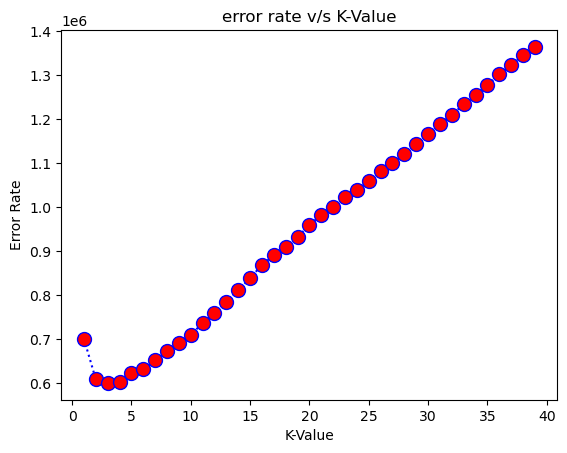

In [28]:
from sklearn.neighbors import KNeighborsRegressor
plt.plot(range(1,40),error_rate,'o:b',mfc='r',ms=10)
plt.title('error rate v/s K-Value')
plt.xlabel('K-Value')
plt.ylabel('Error Rate')
plt.show()

In [29]:
model = KNeighborsRegressor(n_neighbors=3)
model.fit(x_train, y_train)
model.score(x_test, y_test)

0.9621011487467043